Portfolio Project 2

By: Elena Arroyo

In [272]:
#Importing important libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import r2_score

In [212]:
#Reading the full CSV into the file and obtaining summary statistics
realty = pd.read_csv("realtor-data.csv")



In [232]:
#Extracting and cleaning the data

realty2 = realty[realty['state']=='North Carolina']
realty2.to_csv("NCRealty.csv",index=False)
realty3 = pd.read_csv("NCRealty.csv")

#Removing the rows with no values for bed, bath, and house size, as those are plots of land without houses
realty4 = realty3[['bed','bath','price','acre_lot','house_size']].dropna()
realty4.to_csv("CleanNCRealty.csv",index=False)
df = pd.read_csv("CleanNCRealty.csv")
df.describe()


,bed,bath,price,acre_lot,house_size
count,37342.000000,37342.000000,3.734200e+04,37342.000000,37342.000000
mean,3.305126,2.680815,4.383085e+05,7.294212,2084.776900
std,1.090523,1.236920,4.516457e+05,579.480935,1570.926076
min,1.000000,1.000000,1.000000e+00,0.000000,209.000000
25%,3.000000,2.000000,2.349000e+05,0.200000,1396.000000
50%,3.000000,3.000000,3.390000e+05,0.350000,1836.000000
75%,4.000000,3.000000,4.850000e+05,0.680000,2471.000000
max,60.000000,54.000000,1.400000e+07,100000.000000,221374.000000


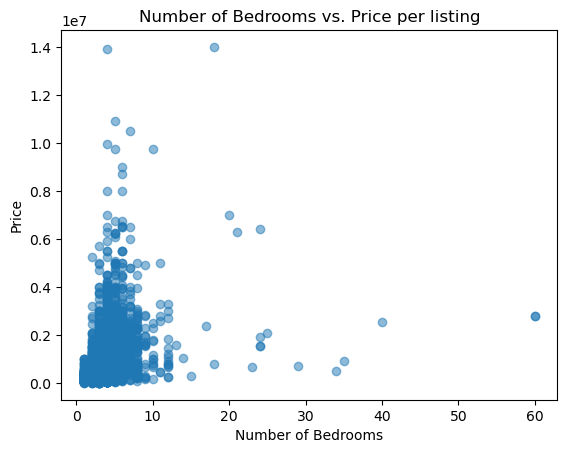

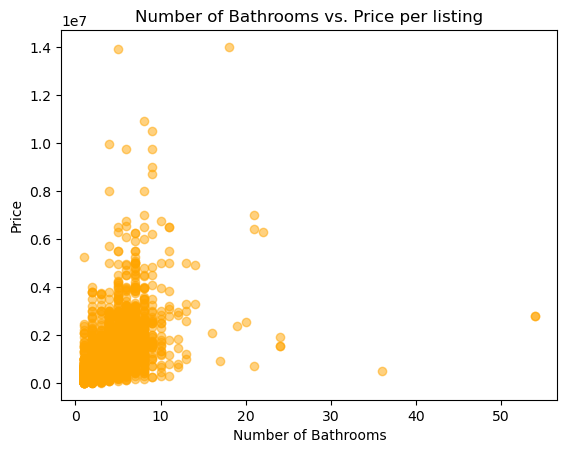

In [244]:
#Helpful Visualizations (bed v price, bath v price)
plt.scatter(df['bed'],df['price'], alpha=0.5)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.title("Number of Bedrooms vs. Price per listing")
plt.show()
plt.scatter(df['bath'],df['price'], alpha=0.5, color="orange")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.title("Number of Bathrooms vs. Price per listing")
plt.show()


R^2: 0.456252819437874
RMSE: 315762.8536117076


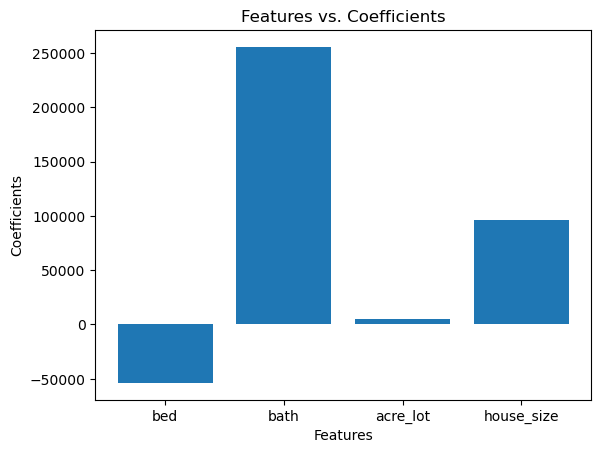

[[-53786.09193127 255663.55307619   4640.42306216  95764.56087142]]


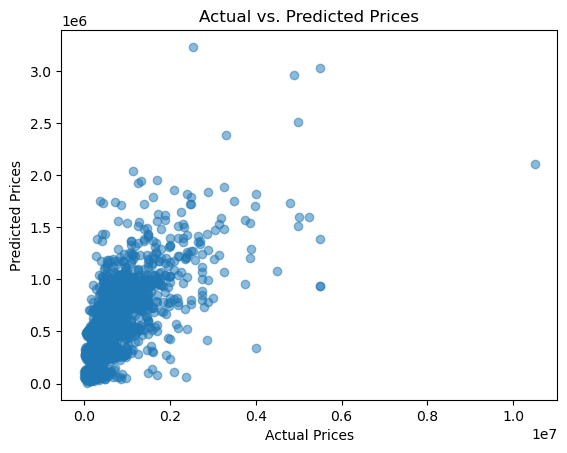

In [339]:
#Assigning X and Y values, and initialiizng the Linear Regression Formula
X = df.drop('price',axis=1).values
y = df['price'].values.reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

#Preventing Data Leakage with Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Initializing the linear regression model
regModel = LinearRegression()
regModel.fit(X_train_scaled,y_train)
y_pred = regModel.predict(X_test_scaled)


#Regression metrics
r2 = regModel.score(X_test_scaled,y_test)
rmse = root_mean_squared_error(y_test,y_pred)

print("R^2: {}".format(r2))
print("RMSE: {}".format(rmse))

#Bar chart of feature coefficients
features_df = df.drop(columns=['price'])
plt.bar(features_df.columns, regModel.coef_.flatten())
plt.title("Features vs. Coefficients")
plt.ylabel("Coefficients")
plt.xlabel("Features")
plt.show()
print(regModel.coef_)


#Scatterplot showing the difference between actual and predicted values
plt.scatter(y_test.flatten(),y_pred.flatten(),alpha=0.5)
plt.title("Actual vs. Predicted Prices")
plt.ylabel("Predicted Prices")
plt.xlabel("Actual Prices")
plt.show()



In [329]:
#Initializing and training the Ridge model in addition to cross-validation
alphas = [0.01, 0.1,1,10,100,10000]
ridge_cv = RidgeCV(alphas=alphas,cv=5)
ridge_cv.fit(X_train_scaled,y_train)
best_alpha = ridge_cv.alpha_

finalRidge = Ridge(alpha=best_alpha)
finalRidge.fit(X_train_scaled,y_train)

yR_pred = finalRidge.predict(X_test_scaled)

print("R^2: {}".format(finalRidge.score(X_test_scaled,y_test)))
print("RMSE: {}".format(root_mean_squared_error(y_test,yR_pred)))




R^2: 0.4197581576633226
RMSE: 326187.30222341645


In [330]:
#Initializing and training the Lasso model
lasso_cv = LassoCV(alphas=alphas,cv=5)
lasso_cv.fit(X_train_scaled,y_train)

best_a = lasso_cv.alpha_
finalLasso = Lasso(alpha=best_a)
finalLasso.fit(X_train_scaled,y_train)
yL_pred = finalLasso.predict(X_test_scaled)

print("R^2: {}".format(finalLasso.score(X_test_scaled,y_test)))
print("RMSE: {}".format(root_mean_squared_error(y_test,yL_pred)))



R^2: 0.45078712738851234
RMSE: 317345.89366473194


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
